In [16]:
import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from collections import Counter
from torchvision import transforms
import yaml
import difflib
# CONFIG 
PLANT_VILLAGE_PATH = r"D:\Code\computer vision\Endterm\PlantVillage-Dataset-master"
PLANTDOC_PATH = r"D:\Code\computer vision\Endterm\PlantDoc"
SPLITS =  r"D:\Code\computer vision\Endterm\PlantVillage-Dataset-master\splits"
DATA_TYPE = "color"
yaml_path = os.path.join(PLANTDOC_PATH, "data.yaml")
raw_dir = os.path.join(PLANT_VILLAGE_PATH,"raw", DATA_TYPE)
PLANT_VILLAGE_CLASS_NAMES = sorted(os.listdir(raw_dir))

CLASS_TO_IDX = {class_name: idx for idx, class_name in enumerate(PLANT_VILLAGE_CLASS_NAMES)}

with open(yaml_path, 'r') as file:
    data_yaml = yaml.safe_load(file)

PLANTDOC_CLASS_NAMES = data_yaml['names']

print("PlantVillage Classes:", PLANT_VILLAGE_CLASS_NAMES)
print("PlantDoc Classes:", PLANTDOC_CLASS_NAMES)


PlantVillage Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite

In [ ]:
def count_plantvillage(split_txt, dataroot):
    counts = Counter()
    with open(split_txt) as f:
        for line in f:
            parts = line.strip().split("/")
            if len(parts) >= 4:
                counts[parts[2]] += 1
    return counts
 
train_txt = os.path.join(SPLITS, f"{DATA_TYPE}_train.txt")
test_txt  = os.path.join(SPLITS, f"{DATA_TYPE}_test.txt")
 
pv_train = count_plantvillage(train_txt, PLANT_VILLAGE_PATH)
pv_test  = count_plantvillage(test_txt,  PLANT_VILLAGE_PATH)
pv_total = Counter({k: pv_train[k] + pv_test[k] for k in set(pv_train) | set(pv_test)})
 
total_pv = sum(pv_total.values())
print(f"PlantVillage total: {total_pv:,} ảnh")
print(f"Train: {sum(pv_train.values()):,} | Test: {sum(pv_test.values()):,}")

split_counts = {"train": 0, "valid": 0, "test": 0}
for split in ["train", "valid", "test"]:
    img_dir = os.path.join(PLANTDOC_PATH, split, "images")
    
    if os.path.exists(img_dir):
        # Đếm số lượng file ảnh (jpg, jpeg, png) trong thư mục
        num_images = len([f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
        split_counts[split] = num_images

total_pd = sum(split_counts.values())

print(f"PlantDoc total: {total_pd:,} ảnh")
print(f"Train: {split_counts['train']:,} | Valid: {split_counts['valid']:,} | Test: {split_counts['test']:,}")

PlantVillage total: 54,305 ảnh
Train: 43,596 | Test: 10,709
PlantDoc total: 2,568 ảnh
Train: 2,008 | Valid: 314 | Test: 246


In [ ]:
# CELL 3 — Đếm ảnh PlantDoc từ label files
PLANTDOC_TO_PV = {}

for pd_cls in PLANTDOC_CLASS_NAMES:
    matches = difflib.get_close_matches(pd_cls, PLANT_VILLAGE_CLASS_NAMES, n=1, cutoff=0.2)
    
    if matches:
        PLANTDOC_TO_PV[pd_cls] = matches[0]
    else:
        PLANTDOC_TO_PV[pd_cls] = "CẦN_ĐIỀN_TAY"

pd_counts    = Counter()
pd_quality   = {}
total_pd     = 0

for split in ["train", "valid", "test"]:
    img_dir   = os.path.join(PLANTDOC_PATH, split, "images")
    label_dir = os.path.join(PLANTDOC_PATH, split, "labels")
    if not os.path.exists(img_dir):
        continue

    img_files = [f for f in os.listdir(img_dir)
                 if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    used = missing = skipped = 0

    for fname in img_files:
        lbl_path = os.path.join(label_dir, os.path.splitext(fname)[0] + ".txt")
        if not os.path.exists(lbl_path):
            missing += 1
            continue
        with open(lbl_path) as f:
            lines = [l.strip() for l in f if l.strip()]
        if not lines:
            missing += 1
            continue
        class_id = max(
            set(int(l.split()[0]) for l in lines),
            key=[int(l.split()[0]) for l in lines].count
        )
        if class_id >= len(PLANTDOC_CLASS_NAMES):
            skipped += 1
            continue
        pd_name = PLANTDOC_CLASS_NAMES[class_id]
        pv_name = PLANTDOC_TO_PV.get(pd_name)
        if pv_name:
            pd_counts[pv_name] += 1
            used += 1
        else:
            skipped += 1

    pd_quality[split] = {
        "Tổng": len(img_files),
        "Dùng được": used,
        "Thiếu nhãn": missing,
        "Class lạ": skipped,
        "Tỉ lệ": f"{used/len(img_files)*100:.1f}%" if img_files else "0%"
    }
    total_pd += used

print("Chất lượng dữ liệu PlantDoc")
print(pd.DataFrame(pd_quality).T.to_string())


Apple Scab Leaf -> Apple___Apple_scab
Apple leaf -> Apple___Apple_scab
Apple rust leaf -> Apple___Apple_scab
Bell_pepper leaf spot -> Tomato___Septoria_leaf_spot
Bell_pepper leaf -> Pepper,_bell___healthy
Blueberry leaf -> Blueberry___healthy
Cherry leaf -> Cherry_(including_sour)___healthy
Corn Gray leaf spot -> Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn leaf blight -> Corn_(maize)___Northern_Leaf_Blight
Corn rust leaf -> Corn_(maize)___Common_rust_
Peach leaf -> Peach___healthy
Potato leaf early blight -> Potato___Early_blight
Potato leaf late blight -> Potato___Late_blight
Potato leaf -> Potato___healthy
Raspberry leaf -> Raspberry___healthy
Soyabean leaf -> Soybean___healthy
Soybean leaf -> Soybean___healthy
Squash Powdery mildew leaf -> Squash___Powdery_mildew
Strawberry leaf -> Strawberry___healthy
Tomato Early blight leaf -> Tomato___Early_blight
Tomato Septoria leaf spot -> Tomato___Septoria_leaf_spot
Tomato leaf bacterial spot -> Tomato___Bacterial_spot
Tomato lea

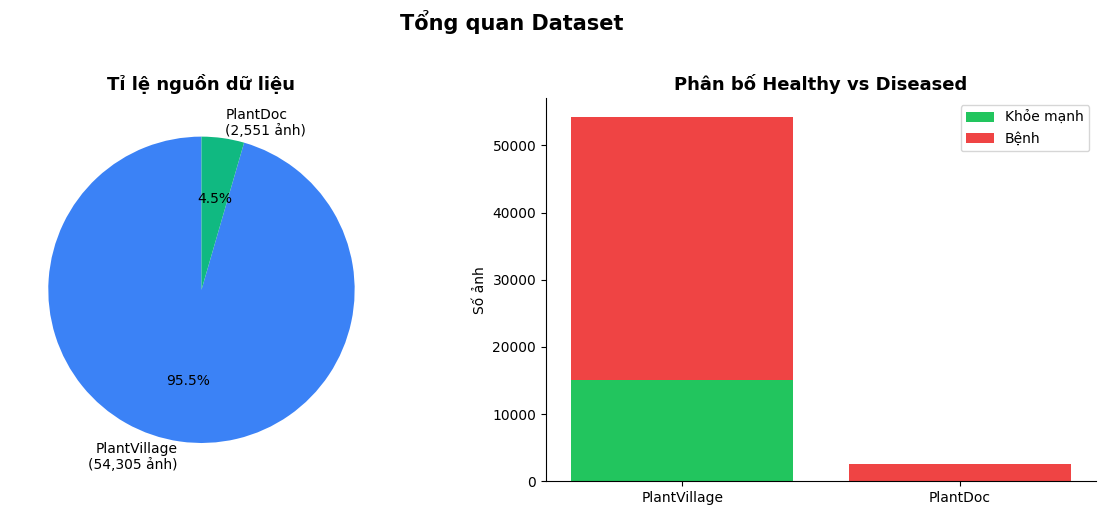

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Pie chart: PV vs PlantDoc
axes[0].pie(
    [total_pv, total_pd],
    labels=[f"PlantVillage\n({total_pv:,} ảnh)", f"PlantDoc\n({total_pd:,} ảnh)"],
    autopct="%1.1f%%",
    colors=["#3b82f6", "#10b981"],
    startangle=90,
)
axes[0].set_title("Tỉ lệ nguồn dữ liệu", fontsize=13, fontweight="bold")
 
# Bar: Healthy vs Diseased
healthy_pv  = sum(v for k, v in pv_total.items() if "healthy" in k)
diseased_pv = total_pv - healthy_pv
disease_keywords = ["blight", "spot", "rust", "rot", "virus", "mold", "mites", "scab"]

healthy_pd = sum(v for k, v in pd_counts.items() if "leaf" in k.lower() and not any(disease in k.lower() for disease in disease_keywords))
diseased_pd = total_pd - healthy_pd
 
x = ["PlantVillage", "PlantDoc"]
axes[1].bar(x, [healthy_pv, healthy_pd],  label="Khỏe mạnh", color="#22c55e")
axes[1].bar(x, [diseased_pv, diseased_pd], bottom=[healthy_pv, healthy_pd], label="Bệnh", color="#ef4444")
axes[1].set_title("Phân bố Healthy vs Diseased", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Số ảnh")
axes[1].legend()
 
for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
 
plt.suptitle("Tổng quan Dataset", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

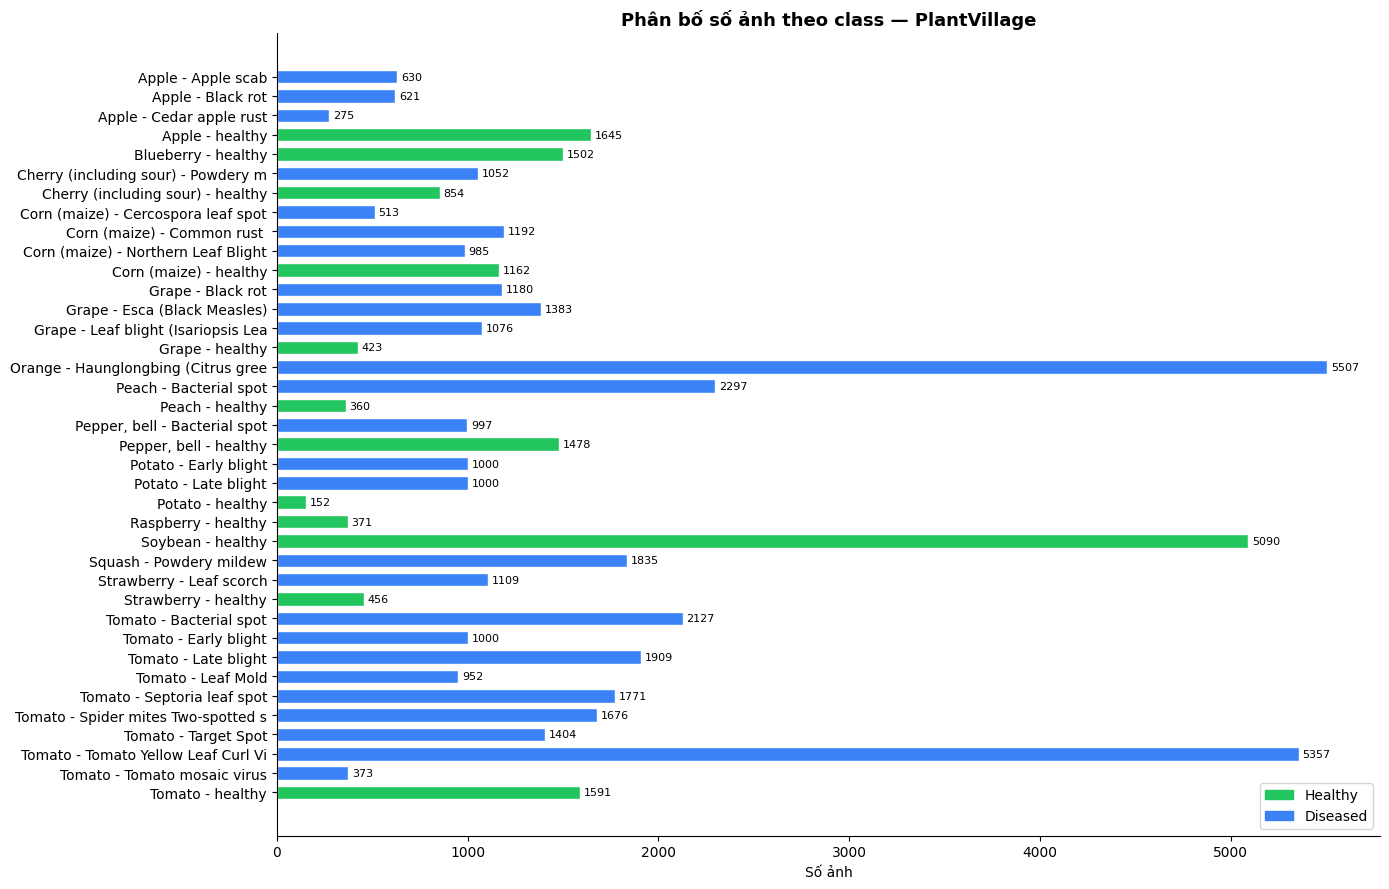

Class ít nhất: 152 ảnh — Potato___healthy
Class nhiều nhất: 5507 ảnh — Orange___Haunglongbing_(Citrus_greening)


In [36]:
short_names = [n.replace("___", " - ").replace("_", " ")[:35] for n in PLANT_VILLAGE_CLASS_NAMES]
counts_pv   = [pv_total.get(n, 0) for n in PLANT_VILLAGE_CLASS_NAMES]
 
colors = ["#22c55e" if "healthy" in n else "#3b82f6" for n in PLANT_VILLAGE_CLASS_NAMES]
 
fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(short_names, counts_pv, color=colors, edgecolor="white", height=0.7)
 
for bar, cnt in zip(bars, counts_pv):
    ax.text(cnt + 20, bar.get_y() + bar.get_height()/2,
            str(cnt), va="center", fontsize=8)
 
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="#22c55e", label="Healthy"),
    Patch(color="#3b82f6", label="Diseased"),
], loc="lower right")
 
ax.set_xlabel("Số ảnh")
ax.set_title("Phân bố số ảnh theo class — PlantVillage", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("eda_class_dist_pv.png", dpi=150)
plt.show()
 
print(f"Class ít nhất: {min(counts_pv)} ảnh — {PLANT_VILLAGE_CLASS_NAMES[counts_pv.index(min(counts_pv))]}")
print(f"Class nhiều nhất: {max(counts_pv)} ảnh — {PLANT_VILLAGE_CLASS_NAMES[counts_pv.index(max(counts_pv))]}")

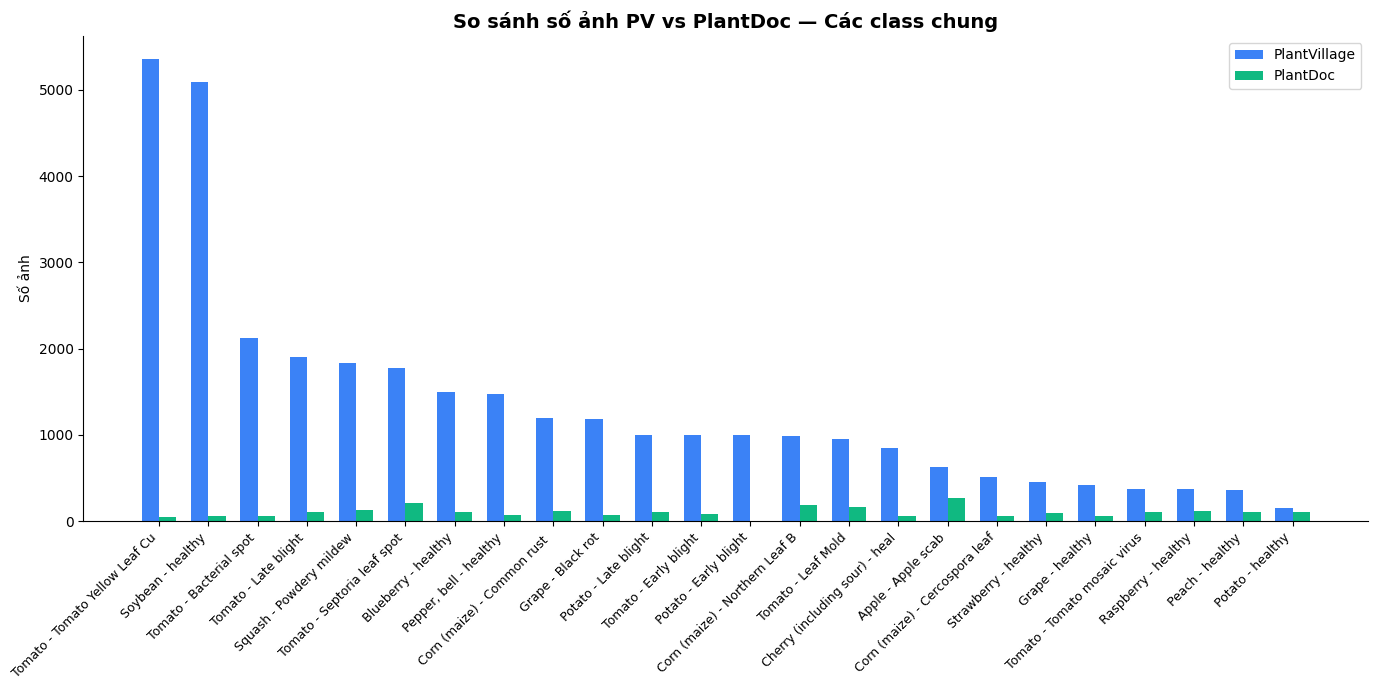

In [ ]:
overlap_classes = []
pv_vals, pd_vals = [], []


unique_mapped_classes = set(PLANTDOC_TO_PV.values())

for pv_name in unique_mapped_classes:
    
    if pv_name in pd_counts and pv_name in pv_total:
        
        # Sửa lỗi mất tên cây: Thay dấu "___" bằng " - "
        short = pv_name.replace("___", " - ").replace("_", " ")[:30]
        
        overlap_classes.append(short)
        pv_vals.append(pv_total[pv_name])
        pd_vals.append(pd_counts[pv_name])

# (Tùy chọn) Sắp xếp các cột theo số lượng ảnh của PlantVillage giảm dần cho đẹp
sorted_data = sorted(zip(pv_vals, pd_vals, overlap_classes), reverse=True)
pv_vals = [val[0] for val in sorted_data]
pd_vals = [val[1] for val in sorted_data]
overlap_classes = [val[2] for val in sorted_data]

# VẼ BIỂU ĐỒ
x = np.arange(len(overlap_classes))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 7)) 
ax.bar(x - w/2, pv_vals, w, label="PlantVillage", color="#3b82f6")
ax.bar(x + w/2, pd_vals, w, label="PlantDoc",     color="#10b981")

ax.set_xticks(x)
# Tăng góc nghiêng lên 45 độ để chữ không bị dính vào nhau
ax.set_xticklabels(overlap_classes, rotation=45, ha="right", fontsize=9) 
ax.set_ylabel("Số ảnh")
ax.set_title("So sánh số ảnh PV vs PlantDoc — Các class chung", fontsize=14, fontweight="bold")

ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("eda_pv_vs_pd.png", dpi=150)
plt.show()

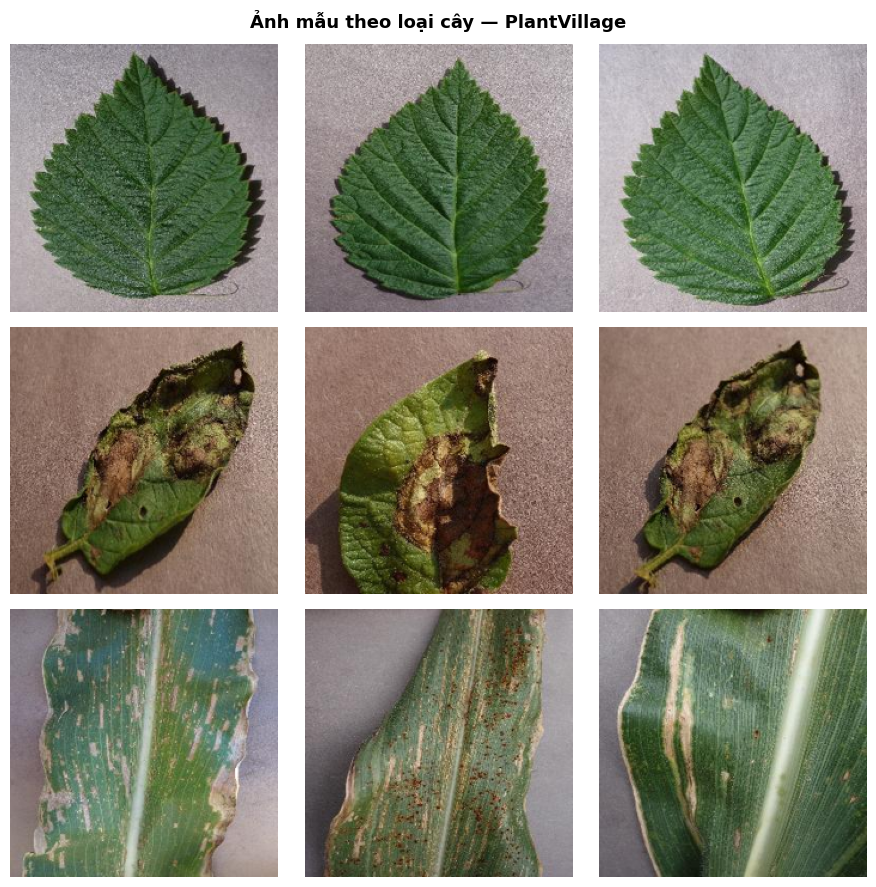

In [44]:
def show_sample_images(root, split_txt, n_crops=3, n_each=3):
    samples_by_crop = {}
    with open(split_txt) as f:
        for line in f:
            rel = line.strip()
            parts = rel.split("/")
            if len(parts) < 4: continue
            crop = parts[2].split("___")[0]
            if crop not in samples_by_crop:
                samples_by_crop[crop] = []
            if len(samples_by_crop[crop]) < n_each:
                samples_by_crop[crop].append(os.path.join(root, rel))
 
    crops = list(samples_by_crop.keys())[:n_crops]
    fig, axes = plt.subplots(n_crops, n_each, figsize=(n_each*3, n_crops*3))
 
    for i, crop in enumerate(crops):
        for j, path in enumerate(samples_by_crop[crop][:n_each]):
            try:
                img = Image.open(path).resize((224, 224))
                axes[i][j].imshow(img)
            except:
                axes[i][j].text(0.5, 0.5, "Error", ha="center")
            axes[i][j].axis("off")
            if j == 0:
                axes[i][j].set_ylabel(crop.replace("_", " "), fontsize=10, rotation=0,
                                       labelpad=60, va="center")
    plt.suptitle("Ảnh mẫu theo loại cây — PlantVillage", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("eda_sample_images.png", dpi=120, bbox_inches="tight")
    plt.show()
 
show_sample_images(PLANT_VILLAGE_PATH, train_txt)

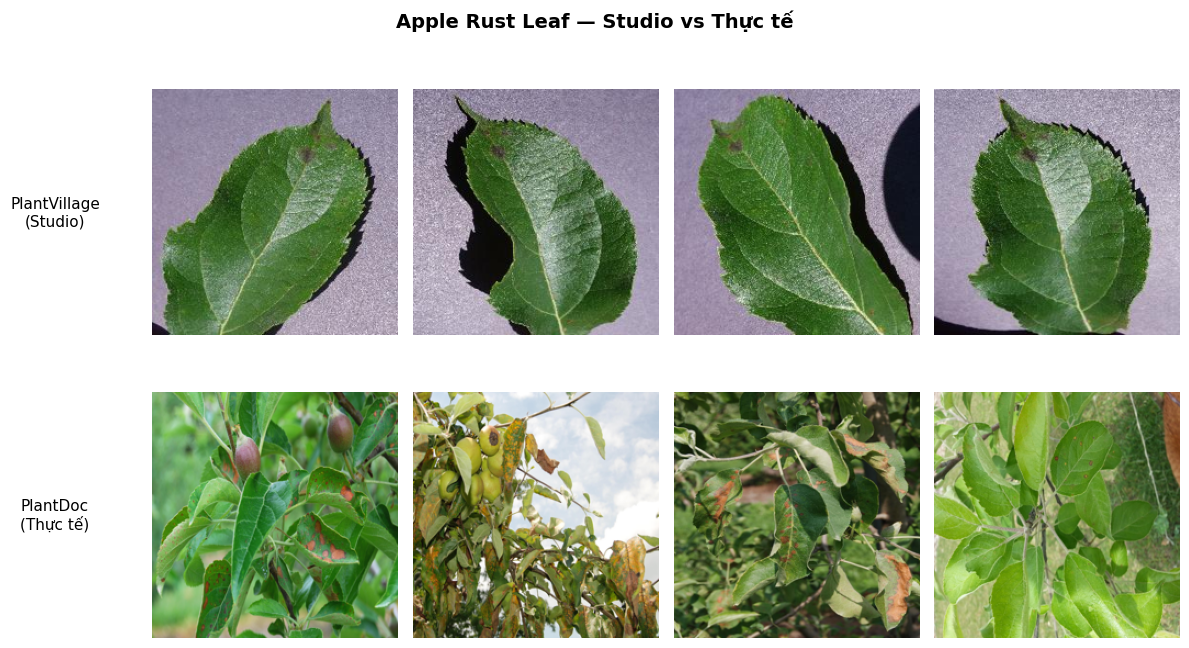

In [49]:
def show_domain_comparison_dynamic(pv_root, pv_txt, pd_root, target_class_name, n=4):
    """
    Hiển thị so sánh ảnh giữa PlantVillage và PlantDoc cho một class bất kỳ.
    target_class_name: Tên class theo chuẩn của PlantDoc (vd: "Apple Scab Leaf")
    """
    # 1. Tra cứu ID và Tên chuẩn
    if target_class_name not in PLANTDOC_CLASS_NAMES:
        print(f"❌ Lỗi: Không tìm thấy class '{target_class_name}' trong danh sách PlantDoc.")
        return
        
    pd_class_id = PLANTDOC_CLASS_NAMES.index(target_class_name)
    pv_class_name = PLANTDOC_TO_PV.get(target_class_name)
    
    if not pv_class_name:
        print(f"❌ Lỗi: Class '{target_class_name}' chưa được map sang PlantVillage.")
        return

    # 2. Lấy ảnh PlantVillage
    pv_paths = []
    with open(pv_txt) as f:
        for line in f:
            rel = line.strip()
            # Tìm dòng chứa đúng tên class chuẩn của PlantVillage
            if pv_class_name in rel:
                pv_paths.append(os.path.join(pv_root, rel))
            if len(pv_paths) >= n: break

    # 3. Lấy ảnh PlantDoc
    pd_paths = []
    pd_img_dir = os.path.join(pd_root, "train", "images")
    pd_lbl_dir = os.path.join(pd_root, "train", "labels")
    
    if os.path.exists(pd_img_dir):
        for fname in os.listdir(pd_img_dir):
            name_no_ext = os.path.splitext(fname)[0]
            lbl_file = os.path.join(pd_lbl_dir, name_no_ext + ".txt")
            
            if os.path.exists(lbl_file):
                with open(lbl_file) as f:
                    lines = [l.strip() for l in f if l.strip()]
                
                classes_in_img = [int(l.split()[0]) for l in lines]
                
                # So sánh với ID tự động tra cứu được ở trên
                if pd_class_id in classes_in_img:
                    pd_paths.append(os.path.join(pd_img_dir, fname))
                    
            if len(pd_paths) >= n: break

    # ==========================================
    # 4. VẼ BIỂU ĐỒ
    # ==========================================
    fig, axes = plt.subplots(2, n, figsize=(n*3, 7))
    labels = ["PlantVillage\n(Studio)", "PlantDoc\n(Thực tế)"]

    for i in range(2):
        for j in range(n):
            axes[i][j].axis("off")

    # Hàng 1: PlantVillage
    for j, path in enumerate(pv_paths[:n]):
        try:
            axes[0][j].imshow(Image.open(path).resize((224, 224)))
        except: pass
    
    if pv_paths:
        axes[0][0].set_ylabel(labels[0], fontsize=11, rotation=0, labelpad=70, va="center")
        axes[0][0].axis("on")
        for spine in axes[0][0].spines.values(): spine.set_visible(False)
        axes[0][0].set_xticks([]); axes[0][0].set_yticks([])

    # Hàng 2: PlantDoc
    for j, path in enumerate(pd_paths[:n]):
        try:
            axes[1][j].imshow(Image.open(path).resize((224, 224)))
        except: pass
    
    if pd_paths:
        axes[1][0].set_ylabel(labels[1], fontsize=11, rotation=0, labelpad=70, va="center")
        axes[1][0].axis("on")
        for spine in axes[1][0].spines.values(): spine.set_visible(False)
        axes[1][0].set_xticks([]); axes[1][0].set_yticks([])

    # Dùng target_class_name làm tiêu đề động
    clean_title = target_class_name.title()
    plt.suptitle(f"{clean_title} — Studio vs Thực tế", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"eda_compare_{target_class_name.replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()
    
show_domain_comparison_dynamic(PLANT_VILLAGE_PATH, train_txt, PLANTDOC_PATH, "Apple rust leaf")

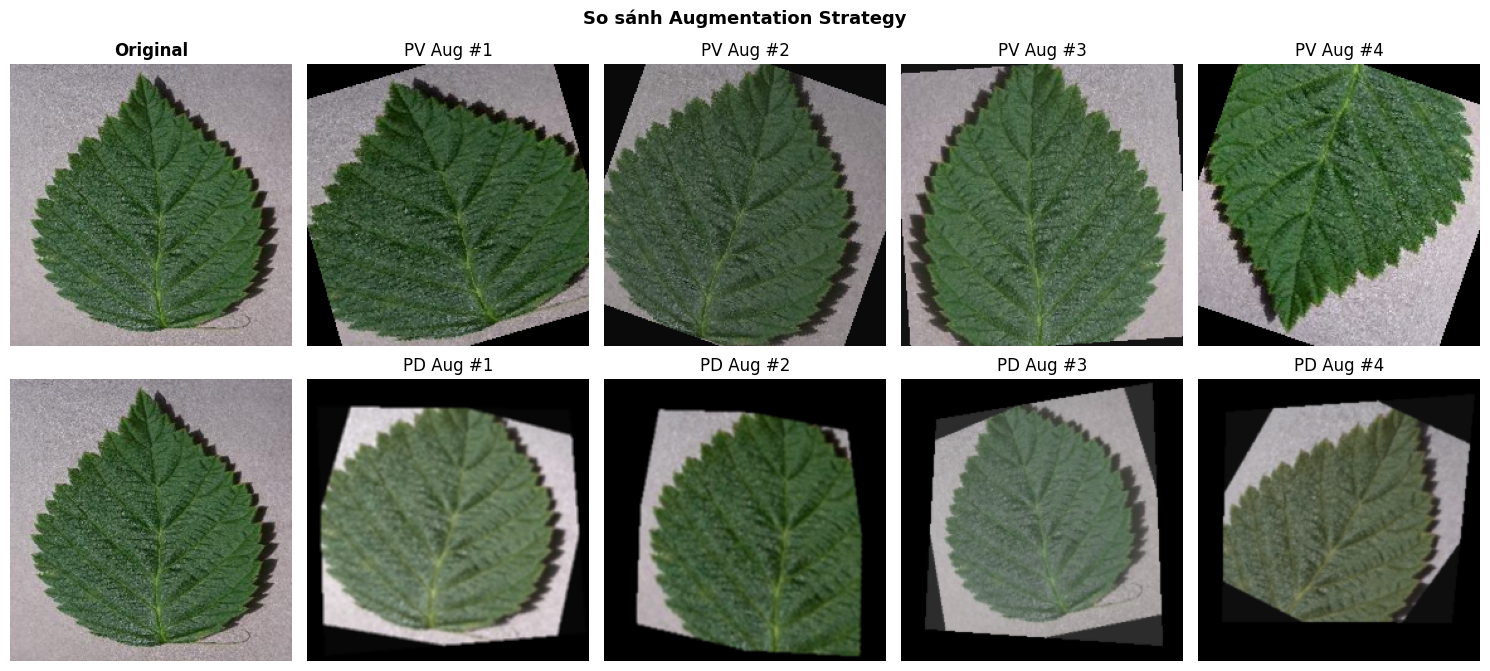

In [52]:
pv_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
])
 
pd_aug = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    transforms.RandomPerspective(distortion_scale=0.3, p=1.0),
    transforms.GaussianBlur(kernel_size=3),
])
 
# Lấy 1 ảnh mẫu
sample_path = None
with open(train_txt) as f:
    for line in f:
        sample_path = os.path.join(PLANT_VILLAGE_PATH, line.strip())
        break
 
if sample_path:
    orig = Image.open(sample_path).convert("RGB")
 
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    axes[0][0].imshow(orig.resize((224,224)))
    axes[0][0].set_title("Original", fontweight="bold")
    axes[0][0].axis("off")
 
    for j in range(1, 5):
        axes[0][j].imshow(pv_aug(orig))
        axes[0][j].set_title(f"PV Aug #{j}")
        axes[0][j].axis("off")
    axes[0][0].set_ylabel("PlantVillage\nAugmentation", fontsize=10, rotation=0, labelpad=80, va="center")
 
    axes[1][0].imshow(orig.resize((224,224)))
    axes[1][0].axis("off")
    for j in range(1, 5):
        axes[1][j].imshow(pd_aug(orig))
        axes[1][j].set_title(f"PD Aug #{j}")
        axes[1][j].axis("off")
    axes[1][0].set_ylabel("PlantDoc\nAugmentation", fontsize=10, rotation=0, labelpad=80, va="center")
 
    plt.suptitle("So sánh Augmentation Strategy", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("eda_augmentation.png", dpi=120, bbox_inches="tight")
    plt.show()

In [53]:
total_combined = total_pv + total_pd
n_disease_classes = sum(1 for n in PLANT_VILLAGE_CLASS_NAMES if "healthy" not in n)
n_healthy_classes = sum(1 for n in PLANT_VILLAGE_CLASS_NAMES if "healthy" in n)
 
summary = pd.DataFrame({
    "Thống kê": [
        "Tổng số ảnh",
        "PlantVillage",
        "PlantDoc",
        "Số classes",
        "Số bệnh",
        "Số healthy",
        "Số loài cây",
        "Class ít ảnh nhất (PV)",
        "Class nhiều ảnh nhất (PV)",
    ],
    "Giá trị": [
        f"{total_combined:,}",
        f"{total_pv:,}",
        f"{total_pd:,}",
        "38",
        str(n_disease_classes),
        str(n_healthy_classes),
        "14",
        f"{min(counts_pv)} ảnh",
        f"{max(counts_pv)} ảnh",
    ]
})
print(summary.to_string(index=False))

                 Thống kê  Giá trị
              Tổng số ảnh   56,856
             PlantVillage   54,305
                 PlantDoc    2,551
               Số classes       38
                  Số bệnh       26
               Số healthy       12
              Số loài cây       14
   Class ít ảnh nhất (PV)  152 ảnh
Class nhiều ảnh nhất (PV) 5507 ảnh
